# Decision Tree

Topics Covered:
- Decision Tree intuition
- Gini Impurity
- Entropy
- Information Gain
- CART Algorithm
- Pre-Pruning vs Post-Pruning
- Evaluation Metrics
- Confusion Matrix
- ROC Curve and AUC
- Feature Importance
- Decision Boundary vs Depth


## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score


## Load Dataset

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Train Decision Tree using Gini

In [4]:
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=4)
tree_gini.fit(X_train, y_train)

pred = tree_gini.predict(X_test)

## Train Decision Tree using Entropy

In [5]:
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4)
tree_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

## Evaluation Metrics

In [6]:
print('Accuracy:', accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))
print('F1 Score:', f1_score(y_test, pred))

Accuracy: 0.9532163742690059
Precision: 0.9716981132075472
Recall: 0.9537037037037037
F1 Score: 0.9626168224299065


## Confusion Matrix

In [7]:
cm = confusion_matrix(y_test, pred)
print(cm)

[[ 60   3]
 [  5 103]]


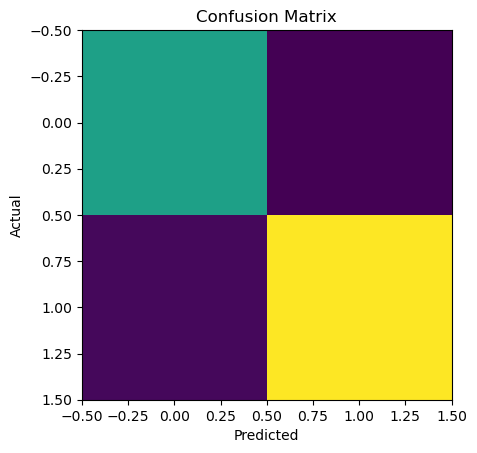

In [8]:
plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## ROC Curve and AUC

In [9]:
probabilities = tree_gini.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)

print('AUC Score:', auc)

AUC Score: 0.9472369194591417


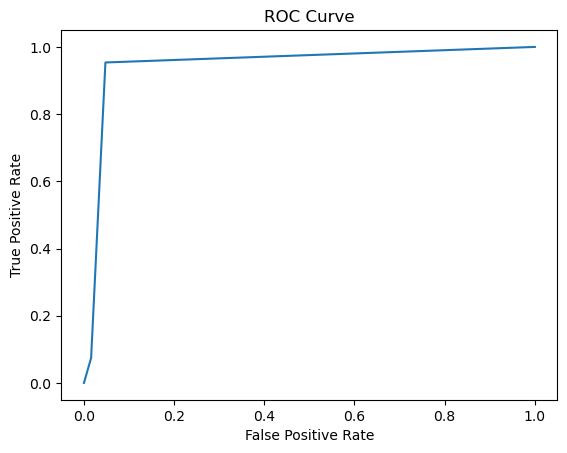

In [10]:
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Visualize Decision Tree

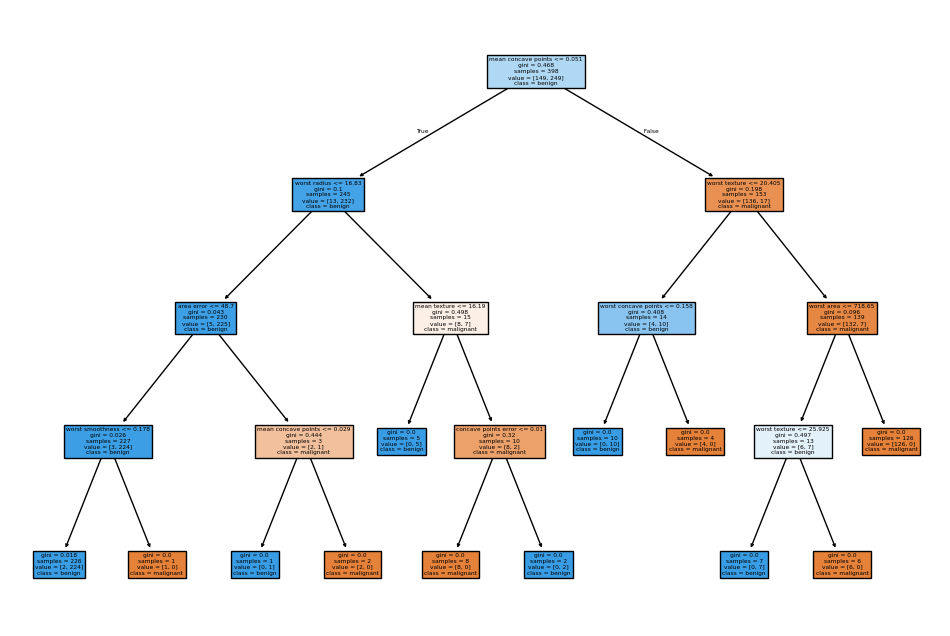

In [11]:
plt.figure(figsize=(12,8))
plot_tree(tree_gini, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()

## Feature Importance

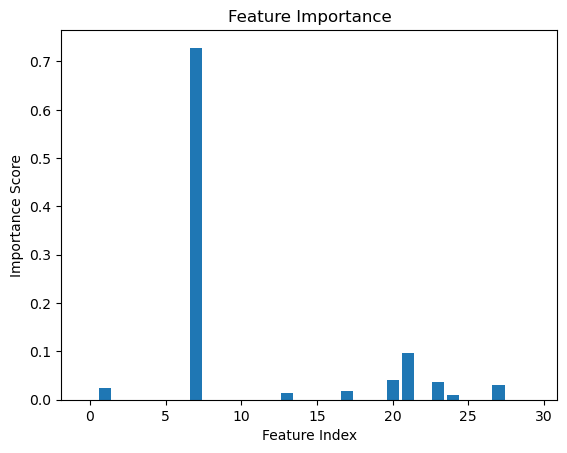

In [12]:
importance = tree_gini.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title('Feature Importance')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.show()

## Cost Complexity Pruning (Post Pruning)

In [13]:
path = tree_gini.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas[:10])

[0.         0.00335008 0.00491483 0.00635319 0.0080402  0.01072027
 0.0143575  0.01623502 0.01716941 0.01852043]
